# EDA 

**피처셋**: 11개 (Return/Ratio 기반)  
**타겟**: `y_t = 1 if Close_t > Close_{t-1}`  
**기간**: 2020-01-02 ~ 2025-05-22

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import ta
import yfinance as yf

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../reports/figures/eda_v2")
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = [
    "NVDA_Return_1D", "NVDA_MA20_ratio", "NVDA_Volume_ratio",
    "NVDA_RSI", "NVDA_MACD",
    "SOX_Return", "TSM_Return",
    "QQQ_Return", "DXY_Return", "US_10Y_Yield",
    "VIX",
]
print("imports OK")

imports OK


## 1. 피처 생성

In [2]:
prices = pd.read_csv(RAW_DIR / "prices_raw.csv", index_col=0, parse_dates=True)

nvda_raw = yf.download("NVDA", start="2019-12-01", end="2025-05-23",
                        auto_adjust=True, progress=False)
prices["NVDA_Volume"] = nvda_raw["Volume"][nvda_raw.index.isin(prices.index)]

nvda = prices["NVDA"]

prices["NVDA_Return_1D"] = nvda.pct_change()
prices["NVDA_MA20_ratio"] = (nvda - nvda.rolling(20).mean()) / nvda.rolling(20).mean()
prices["NVDA_Volume_ratio"] = prices["NVDA_Volume"] / prices["NVDA_Volume"].rolling(20).mean()
prices["NVDA_RSI"] = ta.momentum.RSIIndicator(close=nvda, window=14).rsi()
prices["NVDA_MACD"] = ta.trend.MACD(close=nvda).macd()
prices["SOX_Return"] = prices["SOX"].pct_change()
prices["TSM_Return"] = prices["TSM"].pct_change()
prices["QQQ_Return"] = prices["QQQ"].pct_change()
prices["DXY_Return"] = prices["DXY"].pct_change()
prices["target"] = (nvda > nvda.shift(1)).astype(int)

df = prices[FEATURE_COLS].shift(1).copy()
df["target"] = prices["target"]
df["NVDA_Close"] = nvda  # 시각화용
df.dropna(inplace=True)
df = df[df.index >= "2020-01-02"]

df.to_csv(PROCESSED_DIR / "features_new.csv")
print(f"데이터: {df.shape[0]}행 × {len(FEATURE_COLS)}피처")
print(f"기간: {df.index.min().date()} ~ {df.index.max().date()}")
print(f"타겟 상승: {df['target'].mean()*100:.1f}%")

데이터: 1350행 × 11피처
기간: 2020-01-09 ~ 2025-05-22
타겟 상승: 54.4%


## 2. 타겟 분포

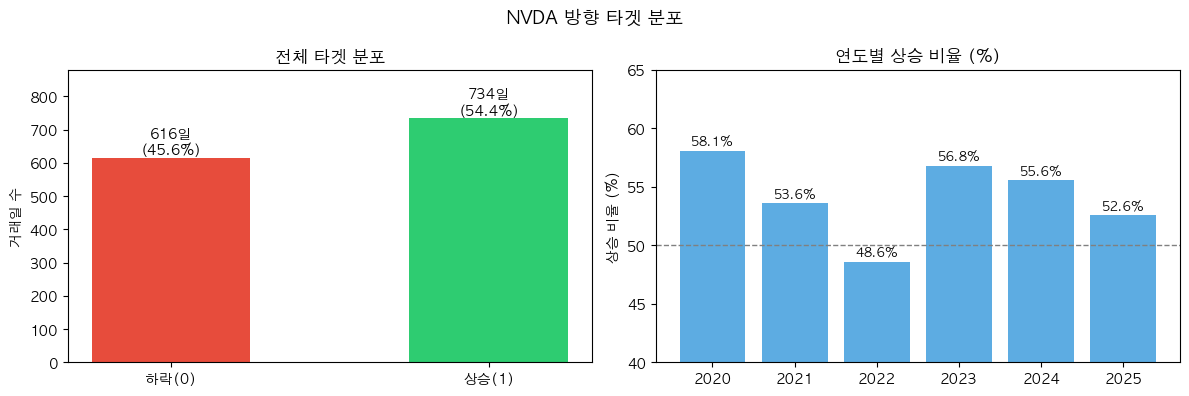

Majority Class baseline: 54.4%
Yesterday Direction baseline: 50.3%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 전체 분포
count = df["target"].value_counts()
axes[0].bar(["하락(0)", "상승(1)"], [count[0], count[1]], color=["#e74c3c", "#2ecc71"], width=0.5)
axes[0].set_title("전체 타겟 분포", fontsize=12)
axes[0].set_ylabel("거래일 수")
axes[0].set_ylim(0, max(count) * 1.2)
for i, (v, r) in enumerate(zip([count[0], count[1]],
                                [count[0]/len(df)*100, count[1]/len(df)*100])):
    axes[0].text(i, v + 10, f"{v}일\n({r:.1f}%)", ha="center", fontsize=10)

# 연도별 상승 비율
yearly = df.groupby(df.index.year)["target"].mean().mul(100)
axes[1].bar(yearly.index.astype(str), yearly.values, color="#3498db", alpha=0.8)
axes[1].axhline(50, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("연도별 상승 비율 (%)", fontsize=12)
axes[1].set_ylabel("상승 비율 (%)")
axes[1].set_ylim(40, 65)
for x, v in enumerate(yearly.values):
    axes[1].text(x, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle("NVDA 방향 타겟 분포", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Majority Class baseline: {df['target'].mean()*100:.1f}%")
print(f"Yesterday Direction baseline: {(df['target'] == df['target'].shift(1)).mean()*100:.1f}%")

## 4. NVDA 주가 시계열 + 주요 이벤트

## 3. 원본 주가 시계열 9종목 (2019-12 ~ 2025-05)

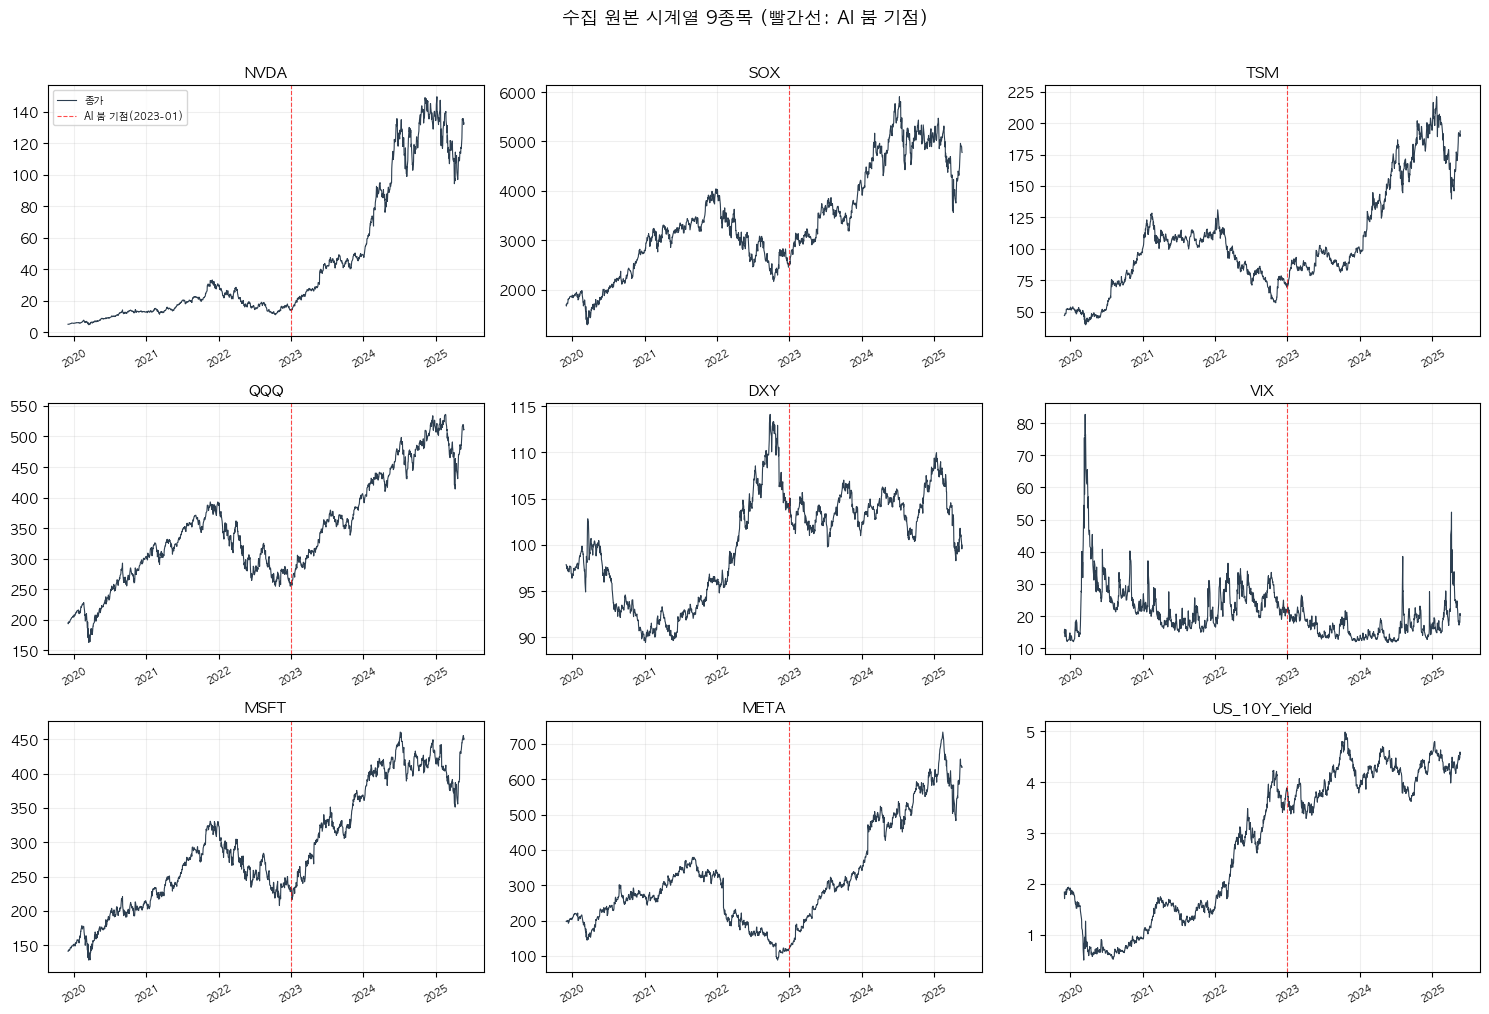

In [4]:
# 피처 생성에 쓴 원본 종목 시계열 확인
prices_raw = pd.read_csv(RAW_DIR / 'prices_raw.csv', index_col=0, parse_dates=True)

TICKERS = {
    'NVDA': 'NVDA', 'SOX': 'SOX', 'TSM': 'TSM',
    'QQQ': 'QQQ', 'DXY': 'DXY', 'VIX': 'VIX',
    'MSFT': 'MSFT', 'META': 'META', 'US_10Y_Yield': 'US_10Y_Yield',
}

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
ai_boom = pd.Timestamp('2023-01-01')

for i, (label, col) in enumerate(TICKERS.items()):
    axes[i].plot(prices_raw.index, prices_raw[col], linewidth=0.8, color='#2c3e50')
    axes[i].axvline(ai_boom, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[i].set_title(label, fontsize=11)
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)
    axes[i].grid(alpha=0.2)

axes[0].legend(['종가', 'AI 붐 기점(2023-01)'], fontsize=7, loc='upper left')
plt.suptitle('수집 원본 시계열 9종목 (빨간선: AI 붐 기점)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '02b_raw_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

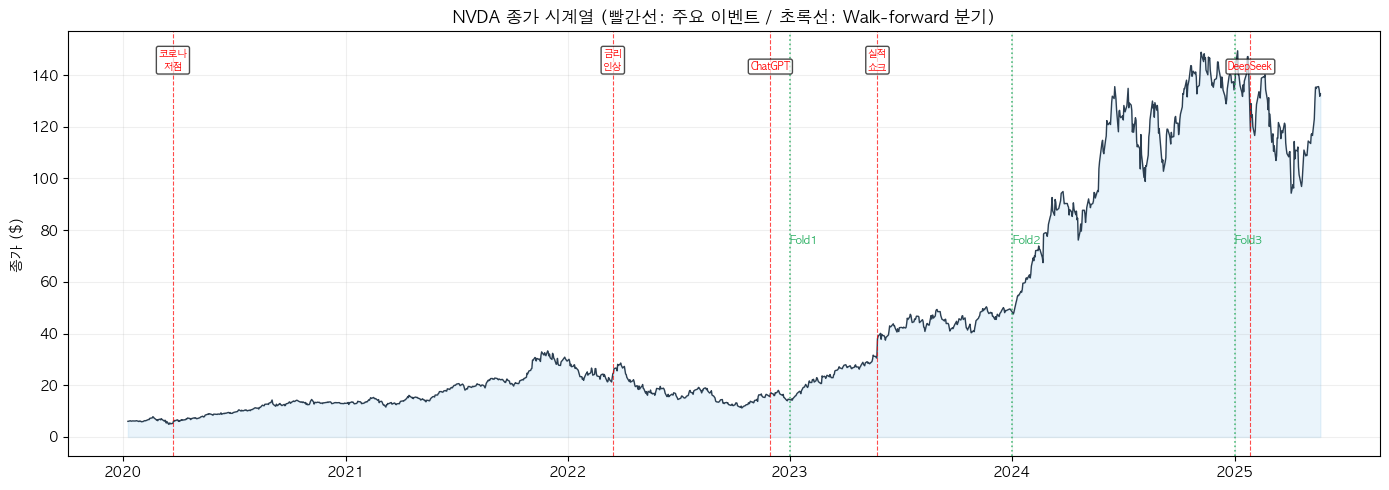

In [5]:
events = {
    "2020-03-23": "코로나\n저점",
    "2022-03-16": "금리\n인상",
    "2022-11-30": "ChatGPT",
    "2023-05-25": "실적\n쇼크",
    "2025-01-27": "DeepSeek",
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["NVDA_Close"], color="#2c3e50", linewidth=1)
ax.fill_between(df.index, df["NVDA_Close"], alpha=0.1, color="#3498db")

for date, label in events.items():
    dt = pd.Timestamp(date)
    if dt in df.index or (dt > df.index.min() and dt < df.index.max()):
        ax.axvline(dt, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
        y_pos = df["NVDA_Close"].max() * 0.95
        ax.text(dt, y_pos, label, ha="center", fontsize=7, color="red",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

# Walk-forward fold 구분선
for fold_date, fold_label in [("2023-01-01", "Fold1"), ("2024-01-01", "Fold2"), ("2025-01-01", "Fold3")]:
    ax.axvline(pd.Timestamp(fold_date), color="#27ae60", linestyle=":", linewidth=1.2, alpha=0.8)
    ax.text(pd.Timestamp(fold_date), df["NVDA_Close"].max() * 0.5,
            fold_label, ha="left", fontsize=8, color="#27ae60")

ax.set_title("NVDA 종가 시계열 (빨간선: 주요 이벤트 / 초록선: Walk-forward 분기)", fontsize=12)
ax.set_ylabel("종가 ($)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_nvda_timeseries_events.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 피처 분포

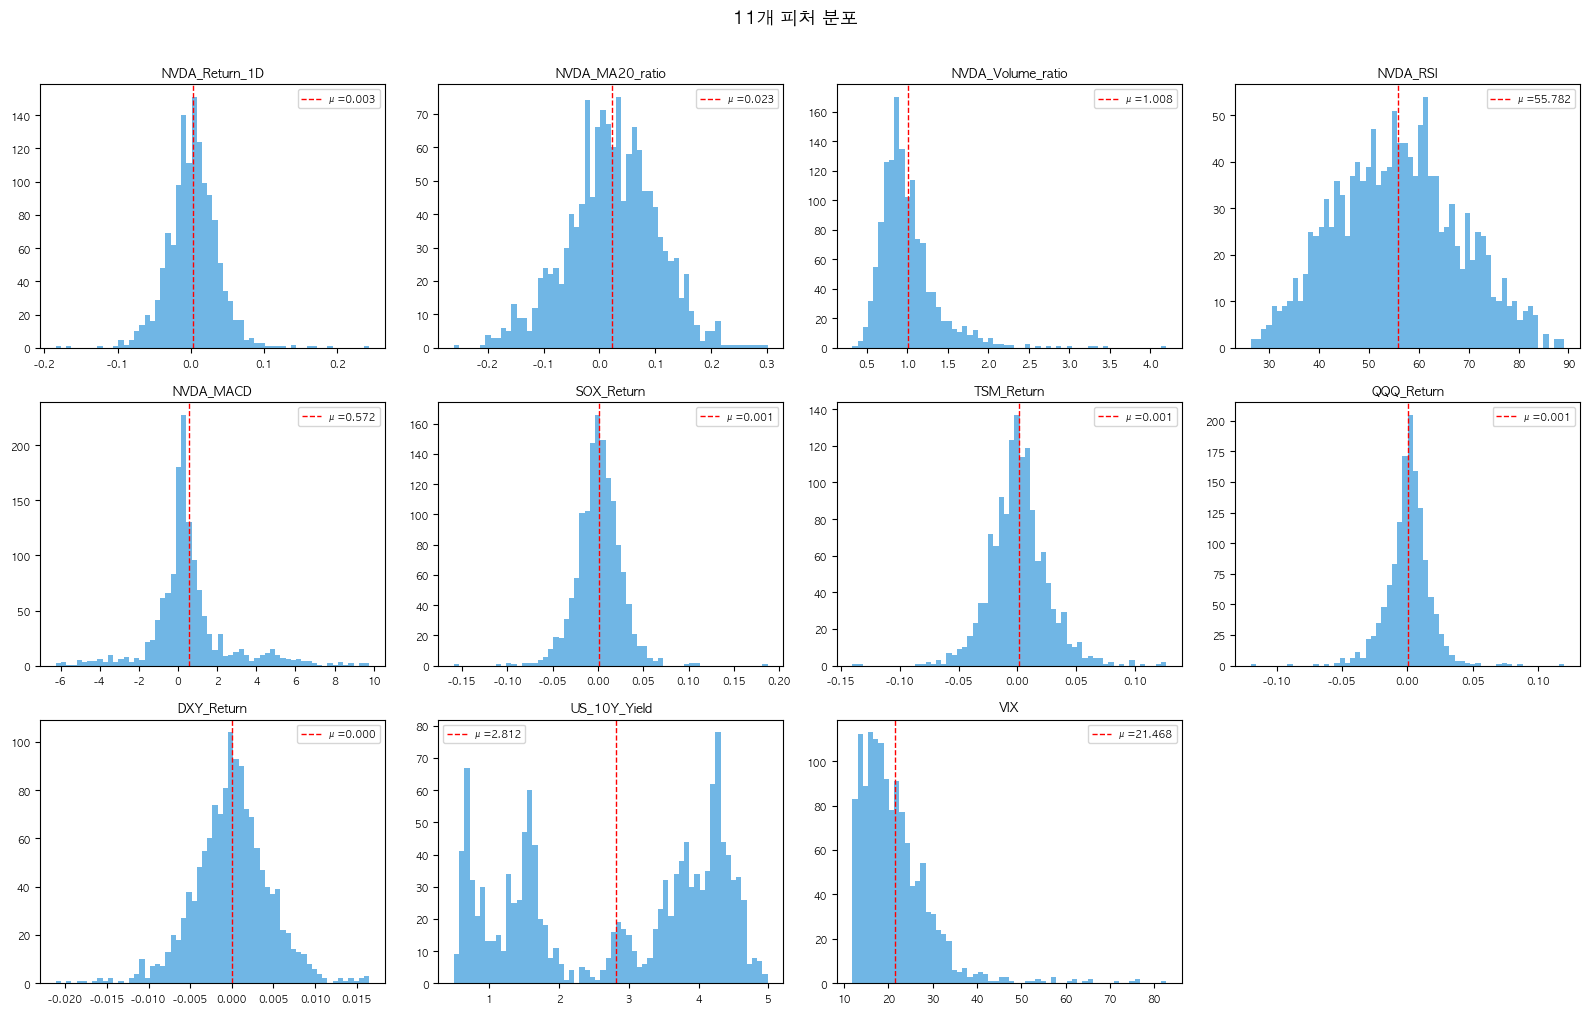

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, color="#3498db", edgecolor="none", alpha=0.7)
    axes[i].axvline(data.mean(), color="red", linewidth=1, linestyle="--", label=f"μ={data.mean():.3f}")
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

# 빈 서브플롯 숨김
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("11개 피처 분포", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 피처 기술통계 및 이상치

In [7]:
desc = df[FEATURE_COLS].describe().T
desc["skewness"] = df[FEATURE_COLS].skew().round(3)
desc["outliers_3sigma"] = ((df[FEATURE_COLS] - df[FEATURE_COLS].mean()).abs()
                           > 3 * df[FEATURE_COLS].std()).sum()
print(desc[["mean", "std", "min", "max", "skewness", "outliers_3sigma"]].round(4))

                      mean      std      min      max  skewness  \
NVDA_Return_1D      0.0029   0.0347  -0.1845   0.2437     0.351   
NVDA_MA20_ratio     0.0232   0.0808  -0.2604   0.3012    -0.103   
NVDA_Volume_ratio   1.0077   0.3631   0.3217   4.1916     2.310   
NVDA_RSI           55.7823  12.2270  26.3727  89.1710     0.123   
NVDA_MACD           0.5722   1.9888  -6.2566   9.7715     0.974   
SOX_Return          0.0010   0.0246  -0.1590   0.1873     0.048   
TSM_Return          0.0013   0.0249  -0.1403   0.1265     0.246   
QQQ_Return          0.0008   0.0166  -0.1198   0.1200    -0.128   
DXY_Return          0.0000   0.0045  -0.0212   0.0165    -0.183   
US_10Y_Yield        2.8116   1.4186   0.4990   4.9880    -0.238   
VIX                21.4681   8.1900  11.8600  82.6900     2.500   

                   outliers_3sigma  
NVDA_Return_1D                  12  
NVDA_MA20_ratio                  5  
NVDA_Volume_ratio               19  
NVDA_RSI                         0  
NVDA_MACD 

## 7. 피처 상관관계 히트맵

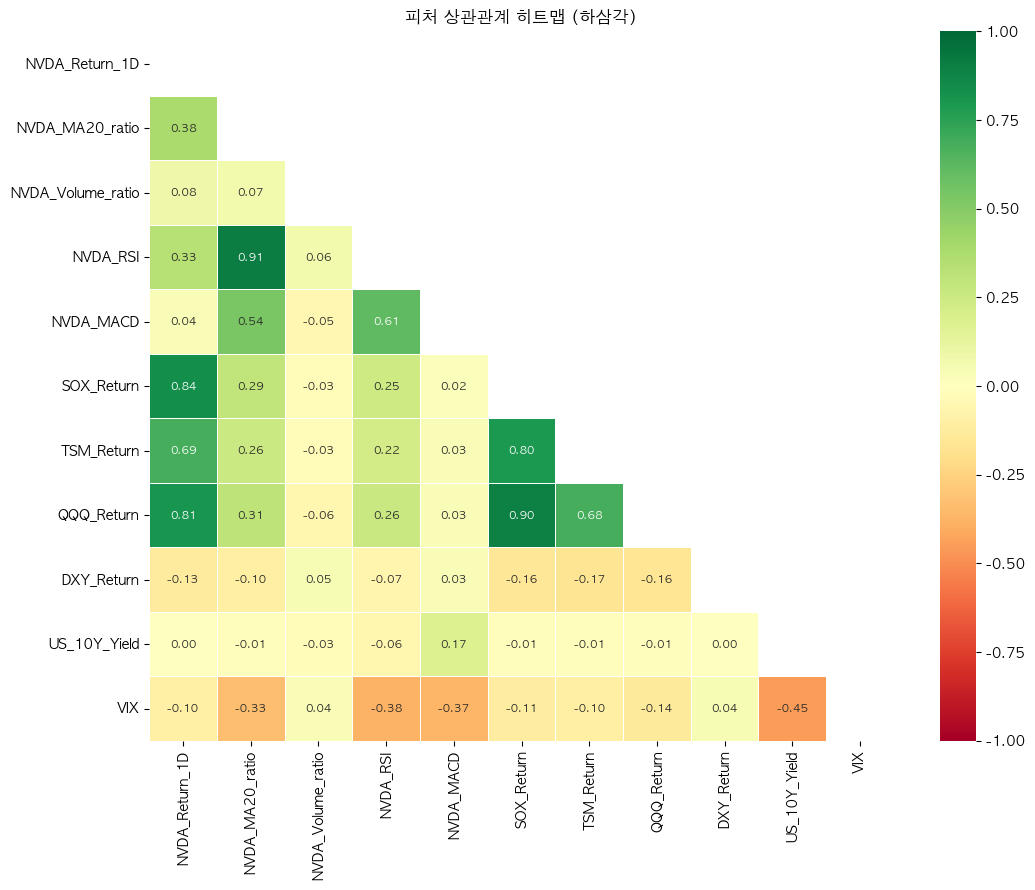

=== |r| > 0.5 피처 쌍 ===
  NVDA_Return_1D         ↔ SOX_Return              r=0.841
  NVDA_Return_1D         ↔ TSM_Return              r=0.687
  NVDA_Return_1D         ↔ QQQ_Return              r=0.810
  NVDA_MA20_ratio        ↔ NVDA_RSI                r=0.911
  NVDA_MA20_ratio        ↔ NVDA_MACD               r=0.538
  NVDA_RSI               ↔ NVDA_MACD               r=0.610
  SOX_Return             ↔ TSM_Return              r=0.795
  SOX_Return             ↔ QQQ_Return              r=0.898
  TSM_Return             ↔ QQQ_Return              r=0.685


In [8]:
corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 8}, linewidths=0.5)
ax.set_title("피처 상관관계 히트맵 (하삼각)", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== |r| > 0.5 피처 쌍 ===")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {corr.index[i]:<22} ↔ {corr.columns[j]:<22}  r={r:.3f}")

## 8. 피처-타겟 상관 (어떤 피처가 방향과 연관되는가)

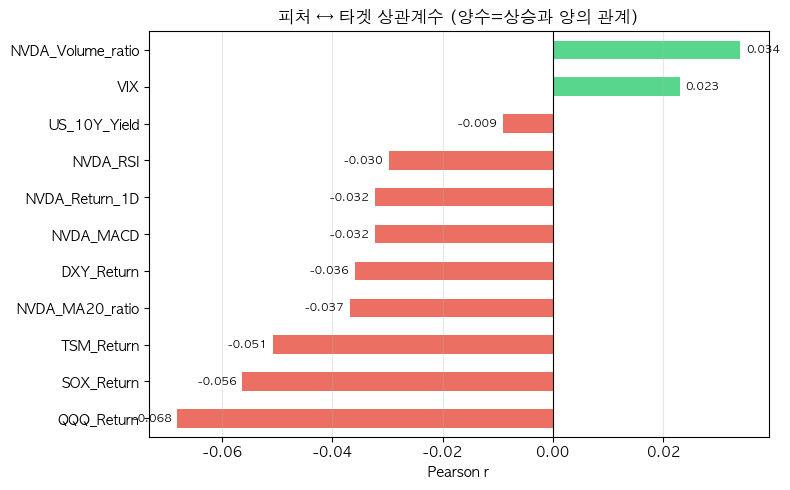

In [9]:
feat_target_corr = df[FEATURE_COLS].corrwith(df["target"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in feat_target_corr]
feat_target_corr.plot(kind="barh", ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("피처 ↔ 타겟 상관계수 (양수=상승과 양의 관계)", fontsize=12)
ax.set_xlabel("Pearson r")
ax.grid(alpha=0.3, axis="x")
for i, v in enumerate(feat_target_corr):
    ax.text(v + 0.001 if v >= 0 else v - 0.001, i,
            f"{v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_feature_target_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Walk-forward 구간별 타겟 분포

         구간  거래일 상승 비율 Majority baseline
Fold1 Train  751 53.4%             53.4%
 Fold1 Test  250 56.8%             56.8%
Fold2 Train 1001 54.2%             54.2%
 Fold2 Test  252 55.6%             55.6%
Fold3 Train 1253 54.5%             54.5%
 Fold3 Test   97 52.6%             52.6%


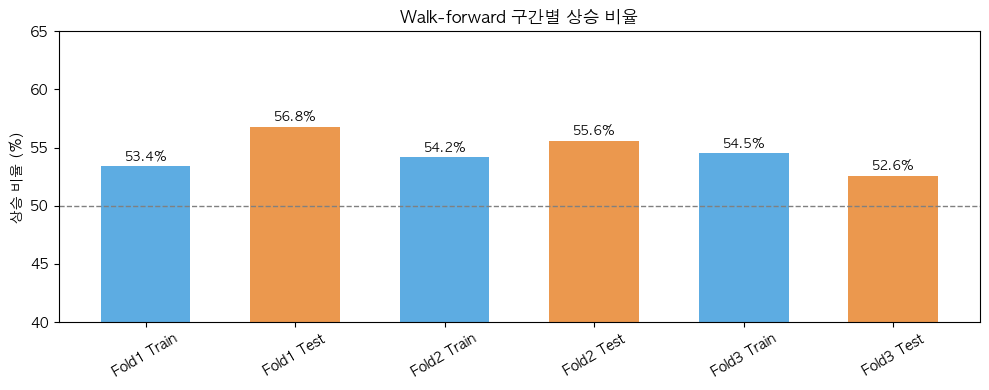

In [10]:
folds = [
    ("Fold1 Train", "2020-01-01", "2022-12-31"),
    ("Fold1 Test",  "2023-01-01", "2023-12-31"),
    ("Fold2 Train", "2020-01-01", "2023-12-31"),
    ("Fold2 Test",  "2024-01-01", "2024-12-31"),
    ("Fold3 Train", "2020-01-01", "2024-12-31"),
    ("Fold3 Test",  "2025-01-01", "2025-12-31"),
]

rows = []
for name, start, end in folds:
    sub = df[(df.index >= start) & (df.index <= end)]
    rows.append({
        "구간": name,
        "거래일": len(sub),
        "상승 비율": f"{sub['target'].mean()*100:.1f}%",
        "Majority baseline": f"{max(sub['target'].mean(), 1-sub['target'].mean())*100:.1f}%",
    })

fold_df = pd.DataFrame(rows)
print(fold_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
labels = [r["구간"] for r in rows]
values = [float(r["상승 비율"].replace("%", "")) for r in rows]
colors = ["#3498db" if "Train" in l else "#e67e22" for l in labels]
bars = ax.bar(labels, values, color=colors, alpha=0.8, width=0.6)
ax.axhline(50, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(40, 65)
ax.set_title("Walk-forward 구간별 상승 비율", fontsize=12)
ax.set_ylabel("상승 비율 (%)")
ax.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_walkforward_target.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. NVDA 이상치 날짜 확인

In [11]:
nvda_ret = df["NVDA_Return_1D"]
threshold = 3 * nvda_ret.std()
outliers = nvda_ret[nvda_ret.abs() > threshold].sort_values()

event_map = {
    "2020-03-16": "코로나 급락",
    "2020-03-12": "코로나 급락",
    "2020-03-17": "코로나 반등",
    "2020-03-13": "코로나 반등",
    "2020-03-24": "코로나 반등",
    "2021-11-04": "실적 서프라이즈",
    "2022-11-10": "CPI 발표",
    "2023-02-23": "실적 발표",
    "2023-05-25": "실적 쇼크 +25%",
    "2024-02-22": "어닝 서프라이즈",
    "2024-07-31": "실적 발표",
    "2025-01-27": "DeepSeek R1 -17%",
    "2025-04-09": "관세 유예 +19%",
}

print(f"이상치 기준: |r| > {threshold:.4f} (3σ)")
print(f"이상치 수: {len(outliers)}건 ({len(outliers)/len(nvda_ret)*100:.1f}%)\n")
print(f"{'날짜':<12} {'수익률':>8}  사건")
print("-" * 40)
for date, val in outliers.items():
    event = event_map.get(str(date.date()), "")
    print(f"{str(date.date()):<12} {val*100:>7.1f}%  {event}")

이상치 기준: |r| > 0.1042 (3σ)
이상치 수: 13건 (1.0%)

날짜                수익률  사건
----------------------------------------
2020-03-17     -18.5%  코로나 반등
2025-01-28     -17.0%  
2020-03-13     -12.2%  코로나 반등
2020-03-18      10.6%  
2020-03-16      11.3%  코로나 급락
2021-11-05      12.0%  
2024-08-01      12.8%  
2023-02-24      14.0%  
2022-11-11      14.3%  
2024-02-23      16.4%  
2020-03-25      17.2%  
2025-04-10      18.7%  
2023-05-26      24.4%  


## 11. 피처 시계열 (상승일 vs 하락일 비교)

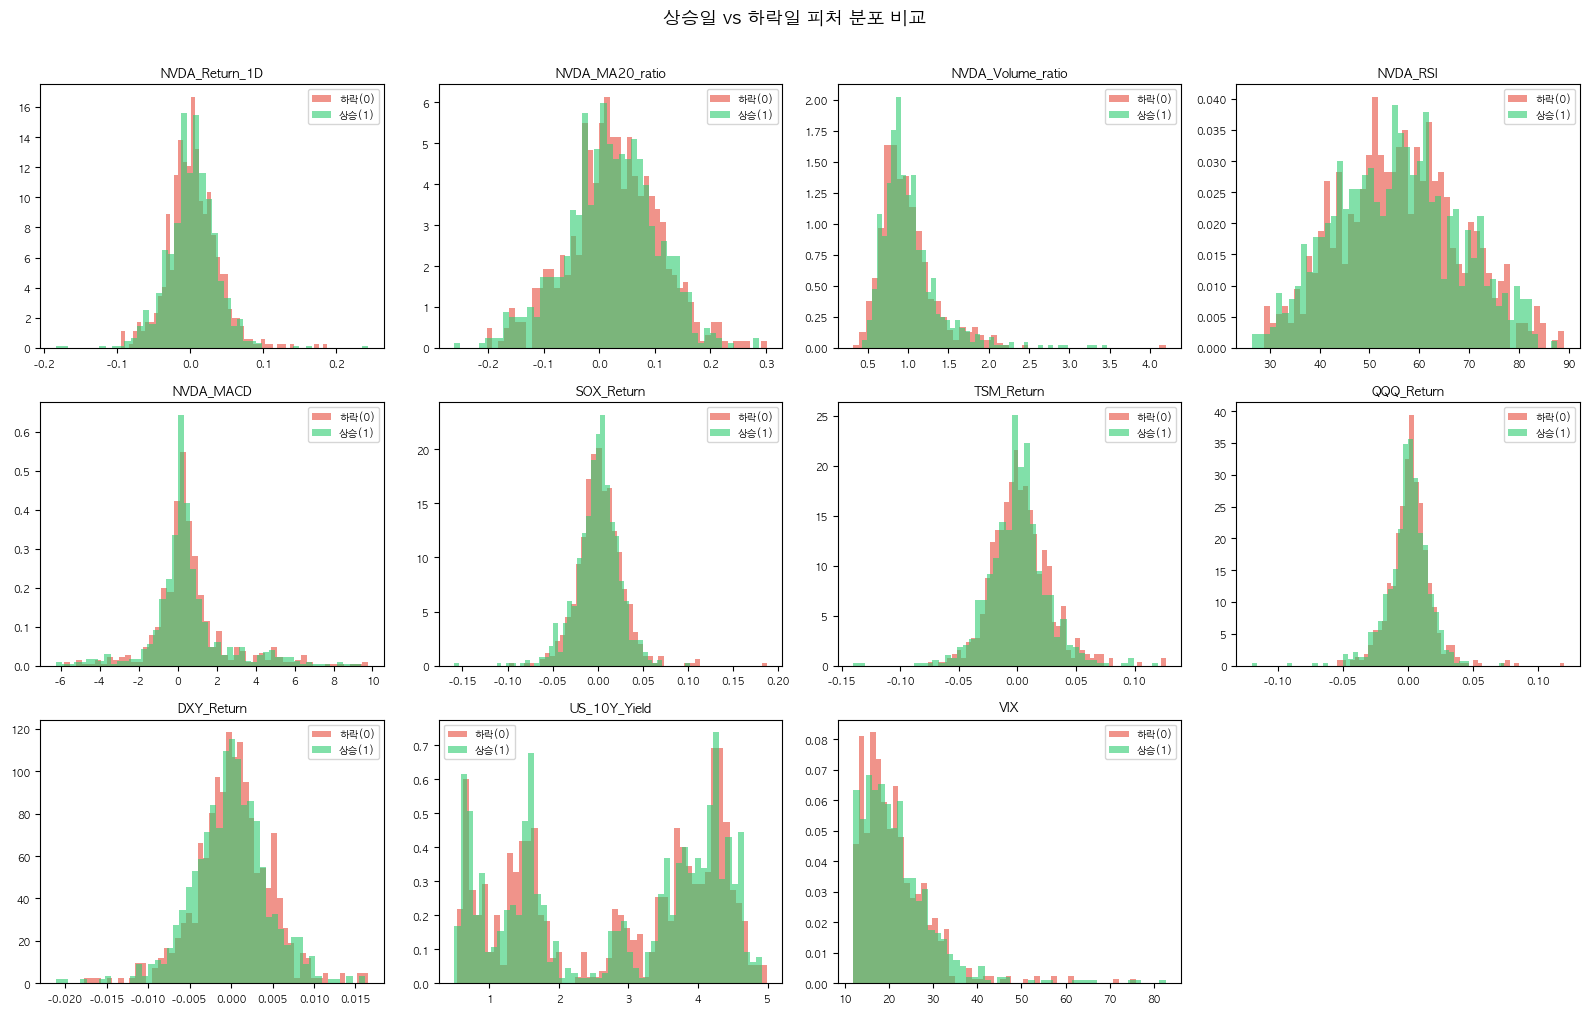

In [12]:
up   = df[df["target"] == 1]
down = df[df["target"] == 0]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(down[col].dropna(), bins=50, alpha=0.6, color="#e74c3c", label="하락(0)", density=True)
    axes[i].hist(up[col].dropna(),   bins=50, alpha=0.6, color="#2ecc71", label="상승(1)", density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("상승일 vs 하락일 피처 분포 비교", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_feature_by_target.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. EDA 요약

In [13]:
print("=" * 55)
print("EDA v2 요약")
print("=" * 55)
print(f"분석 기간        : {df.index.min().date()} ~ {df.index.max().date()}")
print(f"거래일 수        : {len(df):,}일")
print(f"피처 수          : {len(FEATURE_COLS)}개")
print()
print(f"타겟 상승        : {df['target'].mean()*100:.1f}%")
print(f"타겟 하락        : {(1-df['target'].mean())*100:.1f}%")
print(f"Majority baseline: {max(df['target'].mean(), 1-df['target'].mean())*100:.1f}%")
print(f"Yesterday baseline: {(df['target']==df['target'].shift(1)).mean()*100:.1f}%")
print()
print(f"NVDA 이상치      : {len(outliers)}건 (3σ 기준)")
print()
print("피처-타겟 상관 상위 3개:")
top3 = feat_target_corr.abs().sort_values(ascending=False).head(3)
for feat, corr_val in top3.items():
    direction = feat_target_corr[feat]
    print(f"  {feat:<25} r={direction:.3f}")
print()
print("다음 단계: notebooks/03_modeling.ipynb")

EDA v2 요약
분석 기간        : 2020-01-09 ~ 2025-05-22
거래일 수        : 1,350일
피처 수          : 11개

타겟 상승        : 54.4%
타겟 하락        : 45.6%
Majority baseline: 54.4%
Yesterday baseline: 50.3%

NVDA 이상치      : 13건 (3σ 기준)

피처-타겟 상관 상위 3개:
  QQQ_Return                r=-0.068
  SOX_Return                r=-0.056
  TSM_Return                r=-0.051

다음 단계: notebooks/03_modeling.ipynb
